# MST Event Boundary Analysis — Lure Discrimination, Test RT & Effect Sizes
## Lure-bin analyses, test-phase RT, encoding–memory correlations, and effect size summary

In [12]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
import seaborn as sns
from scipy import stats
from pathlib import Path
import os, re, warnings
warnings.filterwarnings('ignore')

plt.rcParams.update({
    'figure.dpi': 150, 'savefig.dpi': 300,
    'font.size': 11, 'font.family': 'serif',
    'axes.labelsize': 12, 'axes.titlesize': 13,
    'xtick.labelsize': 10, 'ytick.labelsize': 10,
    'legend.fontsize': 10, 'figure.figsize': (8, 5),
})

BASE = Path(r'home/sampathravikanti/Downloads/BRSM')
DATA = BASE / 'MST_Data'
print(f'Working directory: {BASE}')

Working directory: home\sampathravikanti\Downloads\BRSM


## 1. Preprocessing & Data Loading

In [2]:
def load_bin_mapping(filepath):
    mapping = {}
    with open(filepath) as f:
        for line in f:
            parts = line.strip().split()
            if len(parts) == 2:
                mapping[int(parts[0])] = int(parts[1])
    return mapping

def extract_item_number(image_path):
    if pd.isna(image_path): return None
    basename = os.path.basename(str(image_path).replace('\\', '/'))
    m = re.match(r'(\d+)', basename)
    return int(m.group(1)) if m else None

def classify_item_type(image_path):
    if pd.isna(image_path): return None
    s = str(image_path).replace('\\', '/')
    if s.lower().startswith('foil'): return 'Foil'
    bn = os.path.basename(s)
    if bn.endswith('a.jpg'): return 'Target'
    if bn.endswith('b.jpg'): return 'Lure'
    return None

def classify_image_category(image_path):
    if pd.isna(image_path): return None
    s = str(image_path).replace('\\', '/').lower()
    return 'Scene' if 'scene' in s else 'Object'

def map_response(key):
    if pd.isna(key): return None
    return {'o': 'Old', 's': 'Similar', 'n': 'New'}.get(str(key).strip().lower())

def map_position(pos):
    if pd.isna(pos): return None
    return {'pre': 'Pre', 'post': 'Post', 'mid': 'Mid', 'none': 'Foil'}.get(str(pos).strip().lower())

print('Preprocessing functions loaded.')

Preprocessing functions loaded.


In [3]:
CONDITIONS = {
    'Task-Only': (DATA/'task_only'/'task_only_data',
                  DATA/'task_only'/'Set6 bins_ob.txt', None),
    'Both':      (DATA/'Both_item_task'/'both_data',
                  DATA/'Both_item_task'/'Set6 bins.txt',
                  DATA/'Both_item_task'/'SetScC bins.txt'),
    'Item-Only': (DATA/'item_only'/'item_only_data',
                  DATA/'item_only'/'Set6 bins.txt',
                  DATA/'item_only'/'SetScC bins.txt'),
}

def load_condition(data_dir, obj_bin_file, scene_bin_file=None):
    obj_bins = load_bin_mapping(obj_bin_file)
    scene_bins = load_bin_mapping(scene_bin_file) if scene_bin_file else {}

    all_files = sorted(os.listdir(data_dir))
    task_by_id = {f[:5]: f for f in all_files if '_task_' in f and f.endswith('.csv')}
    test_by_id = {f[:5]: f for f in all_files if '_test_' in f and f.endswith('.csv')}
    valid_ids = sorted(set(task_by_id) & set(test_by_id))

    enc_records, test_records = [], []
    for pid in valid_ids:
        # Encoding phase
        tf = pd.read_csv(data_dir / task_by_id[pid])
        trials = tf[tf['trials.thisN'].notna()].copy()
        if len(trials) == 0: continue
        trials['participant'] = pid
        trials['block'] = trials['trials.thisN'].astype(int) // 7
        trials['pos_in_block'] = trials['trials.thisN'].astype(int) % 7
        trials['boundary_pos'] = trials['pos_in_block'].map(
            lambda p: 'Post' if p == 0 else ('Pre' if p == 6 else 'Mid'))
        def compute_rt(row):
            if pd.notna(row.get('key_resp_9.rt')): return row['key_resp_9.rt'] * 1000
            if pd.notna(row.get('key_resp_8.rt')): return 3000 + row['key_resp_8.rt'] * 1000
            return np.nan
        trials['rt_ms'] = trials.apply(compute_rt, axis=1)
        if 'encoding_task_accuracy' in tf.columns:
            ea = tf['encoding_task_accuracy'].dropna()
            trials['encoding_accuracy'] = ea.iloc[-1] if len(ea) else np.nan
        else:
            trials['encoding_accuracy'] = np.nan
        enc_records.append(trials[['participant','image_path','block','pos_in_block',
                                   'boundary_pos','rt_ms','encoding_accuracy',
                                   'key_resp_9.keys','key_resp_8.keys']].copy())

        # Test phase
        testf = pd.read_csv(data_dir / test_by_id[pid])
        ttrials = testf[testf['image_path'].notna()].copy()
        if len(ttrials) == 0: continue
        ttrials['participant'] = pid
        ttrials['item_type'] = ttrials['image_path'].apply(classify_item_type)
        ttrials['position'] = ttrials['position_of_stimuli'].apply(map_position)
        ttrials['response'] = ttrials['key_resp_3.keys'].apply(map_response)
        ttrials['test_rt'] = ttrials['key_resp_3.rt'] * 1000
        ttrials['item_number'] = ttrials['image_path'].apply(extract_item_number)
        ttrials['img_category'] = ttrials['image_path'].apply(classify_image_category)
        def get_bin(row):
            if row['item_type'] != 'Lure': return np.nan
            n = row['item_number']; c = row['img_category']
            if c == 'Scene' and n in scene_bins: return scene_bins[n]
            if n in obj_bins: return obj_bins[n]
            return np.nan
        ttrials['lure_bin'] = ttrials.apply(get_bin, axis=1)
        test_records.append(ttrials[['participant','image_path','item_type','position',
                                     'response','test_rt','item_number','img_category',
                                     'lure_bin']].copy())

    enc_df = pd.concat(enc_records, ignore_index=True) if enc_records else pd.DataFrame()
    test_df = pd.concat(test_records, ignore_index=True) if test_records else pd.DataFrame()
    return enc_df, test_df

all_enc, all_test = {}, {}
for cond, (ddir, obj_f, sc_f) in CONDITIONS.items():
    enc, tst = load_condition(ddir, obj_f, sc_f)
    all_enc[cond] = enc; all_test[cond] = tst
    n = enc['participant'].nunique() if len(enc) else 0
    print(f'  {cond}: {n} participants, {len(enc)} enc trials, {len(tst)} test trials')

  Task-Only: 53 participants, 14840 enc trials, 7950 test trials
  Both: 49 participants, 13720 enc trials, 7350 test trials
  Item-Only: 56 participants, 15680 enc trials, 8400 test trials


In [4]:
# ── Compute REC and LDI (needed for later analyses) ──

def compute_rec_ldi(test_df):
    results = []
    for pid in test_df['participant'].unique():
        pdata = test_df[test_df['participant'] == pid]
        foils = pdata[pdata['item_type'] == 'Foil']
        n_f = len(foils[foils['response'].notna()])
        if n_f == 0: continue
        p_old_foil = (foils['response'] == 'Old').sum() / n_f
        p_sim_foil = (foils['response'] == 'Similar').sum() / n_f
        for pos in ['Pre', 'Mid', 'Post']:
            targs = pdata[(pdata['item_type']=='Target') & (pdata['position']==pos)]
            nt = len(targs[targs['response'].notna()])
            p_old_t = (targs['response']=='Old').sum()/nt if nt else np.nan
            lures = pdata[(pdata['item_type']=='Lure') & (pdata['position']==pos)]
            nl = len(lures[lures['response'].notna()])
            p_sim_l = (lures['response']=='Similar').sum()/nl if nl else np.nan
            results.append({
                'participant': pid, 'position': pos,
                'REC': p_old_t - p_old_foil if not np.isnan(p_old_t) else np.nan,
                'LDI': p_sim_l - p_sim_foil if not np.isnan(p_sim_l) else np.nan,
                'p_old_target': p_old_t, 'p_sim_lure': p_sim_l,
                'p_old_foil': p_old_foil, 'p_sim_foil': p_sim_foil,
            })
    return pd.DataFrame(results)

rec_ldi_all = {cond: compute_rec_ldi(tdf) for cond, tdf in all_test.items()}
print('REC & LDI computed for all conditions.')

REC & LDI computed for all conditions.


## 2. LDI by Lure Similarity Bin

Lure bins range from 1 (most similar to target) to 5 (least similar).  
LDI should decrease as lures become more similar to targets.

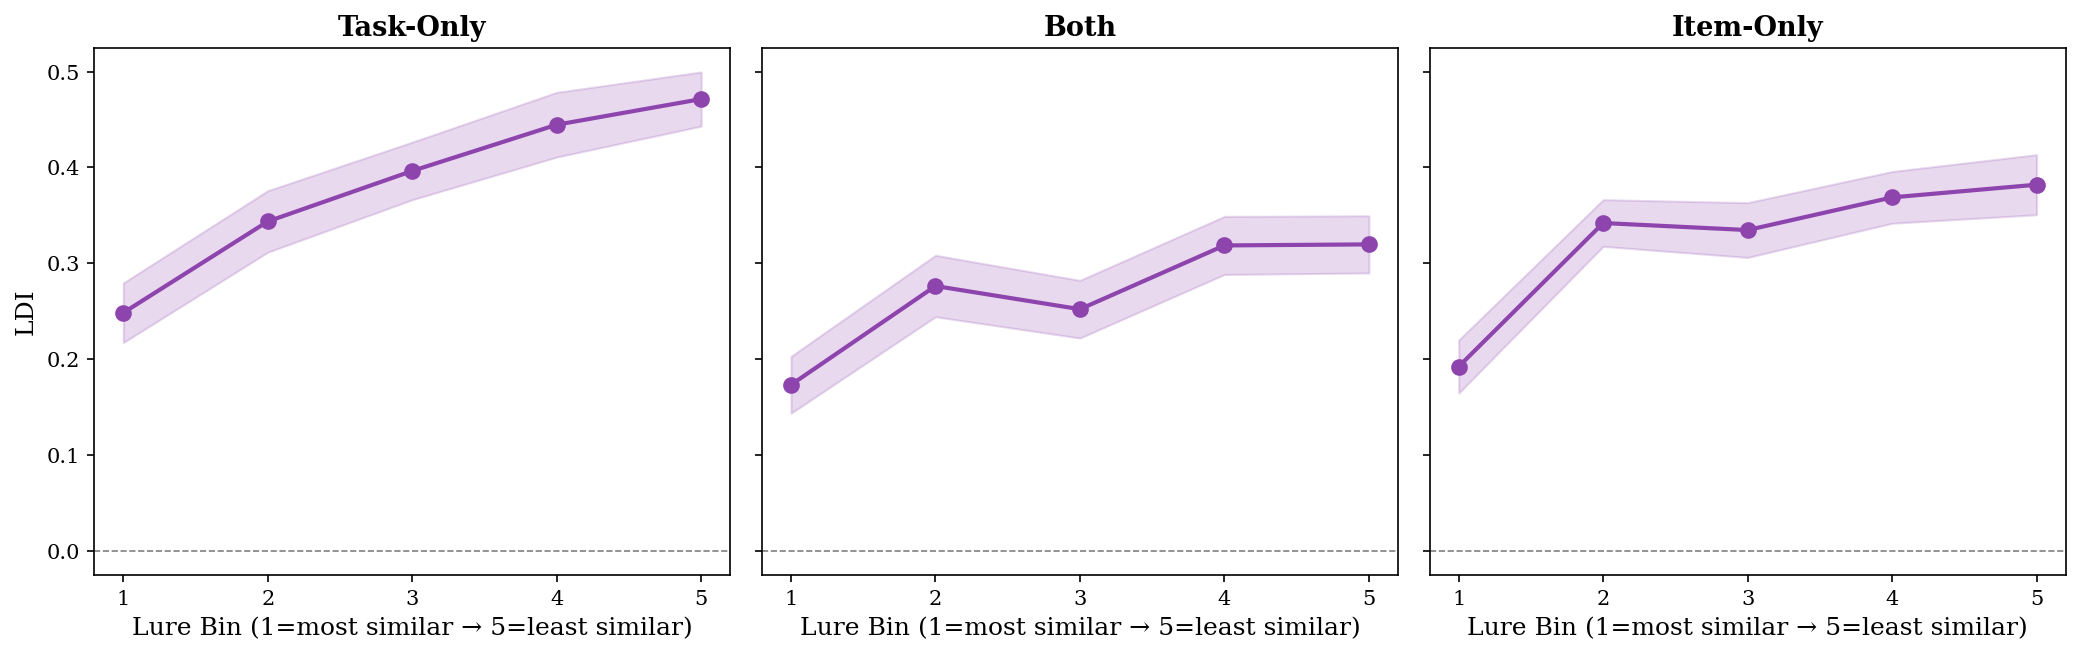

In [5]:
# ── Figure 4: LDI by lure bin — all conditions ──
fig, axes = plt.subplots(1, 3, figsize=(14, 4.5), sharey=True)

for idx, (cond, test_df) in enumerate(all_test.items()):
    ax = axes[idx]
    
    # Per-participant foil 'similar' rate
    foil_rates = {}
    for pid in test_df['participant'].unique():
        pdata = test_df[test_df['participant'] == pid]
        foils = pdata[pdata['item_type'] == 'Foil']
        n = len(foils[foils['response'].notna()])
        foil_rates[pid] = (foils['response'] == 'Similar').sum() / n if n > 0 else 0
    
    lures = test_df[(test_df['item_type'] == 'Lure') & (test_df['lure_bin'].notna())].copy()
    
    bin_means, bin_sems = [], []
    for b in range(1, 6):
        bin_lures = lures[lures['lure_bin'] == b]
        participant_ldis = []
        for pid in bin_lures['participant'].unique():
            psub = bin_lures[bin_lures['participant'] == pid]
            n = len(psub[psub['response'].notna()])
            if n == 0: continue
            p_sim = (psub['response'] == 'Similar').sum() / n
            participant_ldis.append(p_sim - foil_rates.get(pid, 0))
        bin_means.append(np.mean(participant_ldis))
        bin_sems.append(np.std(participant_ldis) / np.sqrt(len(participant_ldis)))
    
    bins = range(1, 6)
    ax.plot(bins, bin_means, 'o-', color='#8e44ad', linewidth=2, markersize=7)
    ax.fill_between(bins, np.array(bin_means) - np.array(bin_sems),
                    np.array(bin_means) + np.array(bin_sems),
                    alpha=0.2, color='#8e44ad')
    ax.axhline(0, color='gray', linestyle='--', linewidth=0.8)
    ax.set_xlabel('Lure Bin (1=most similar → 5=least similar)')
    ax.set_ylabel('LDI' if idx == 0 else '')
    ax.set_title(f'{cond}', fontweight='bold')
    ax.set_xticks(range(1, 6))

plt.tight_layout()
plt.savefig(BASE / 'fig4_ldi_bin.pdf', bbox_inches='tight')
plt.savefig(BASE / 'fig4_ldi_bin.png', bbox_inches='tight')
plt.show()

## 3. Lure Bin × Boundary Position Interaction

Does the boundary effect on lure discrimination depend on lure similarity?

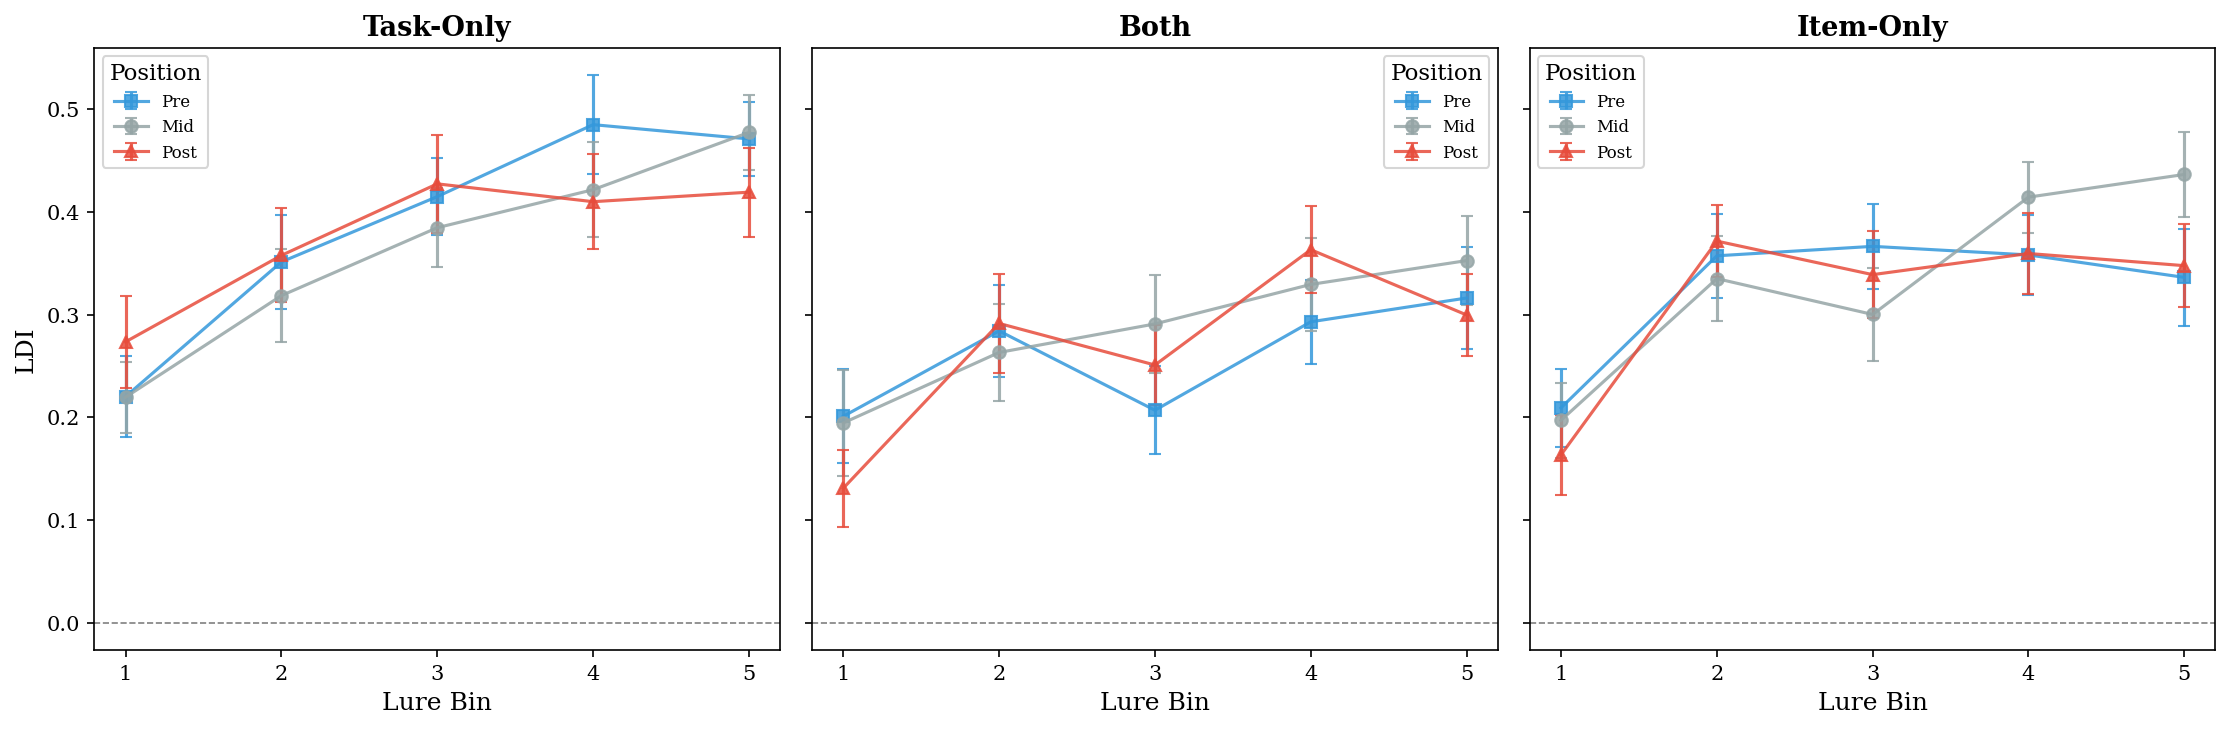

In [6]:
# ── Figure 5: LDI by lure bin × boundary position — all conditions ──
fig, axes = plt.subplots(1, 3, figsize=(15, 5), sharey=True)
pos_colors = {'Pre': '#3498db', 'Mid': '#95a5a6', 'Post': '#e74c3c'}
pos_markers = {'Pre': 's', 'Mid': 'o', 'Post': '^'}

for idx, (cond, test_df) in enumerate(all_test.items()):
    ax = axes[idx]
    
    # Foil base rates
    foil_rates = {}
    for pid in test_df['participant'].unique():
        pdata = test_df[test_df['participant'] == pid]
        foils = pdata[pdata['item_type'] == 'Foil']
        n = len(foils[foils['response'].notna()])
        foil_rates[pid] = (foils['response'] == 'Similar').sum() / n if n > 0 else 0
    
    lures = test_df[(test_df['item_type'] == 'Lure') & (test_df['lure_bin'].notna())].copy()
    
    for pos in ['Pre', 'Mid', 'Post']:
        pos_lures = lures[lures['position'] == pos]
        bin_means, bin_sems = [], []
        
        for b in range(1, 6):
            bin_sub = pos_lures[pos_lures['lure_bin'] == b]
            participant_ldis = []
            for pid in bin_sub['participant'].unique():
                psub = bin_sub[bin_sub['participant'] == pid]
                n = len(psub[psub['response'].notna()])
                if n == 0: continue
                p_sim = (psub['response'] == 'Similar').sum() / n
                participant_ldis.append(p_sim - foil_rates.get(pid, 0))
            
            if participant_ldis:
                bin_means.append(np.mean(participant_ldis))
                bin_sems.append(np.std(participant_ldis) / np.sqrt(len(participant_ldis)))
            else:
                bin_means.append(np.nan)
                bin_sems.append(np.nan)
        
        ax.errorbar(range(1, 6), bin_means, yerr=bin_sems,
                    fmt=f'{pos_markers[pos]}-', color=pos_colors[pos],
                    linewidth=1.5, markersize=6, capsize=3, label=pos, alpha=0.85)
    
    ax.axhline(0, color='gray', linestyle='--', linewidth=0.8)
    ax.set_xlabel('Lure Bin')
    ax.set_ylabel('LDI' if idx == 0 else '')
    ax.set_title(f'{cond}', fontweight='bold')
    ax.set_xticks(range(1, 6))
    ax.legend(title='Position', fontsize=8)

plt.tight_layout()
plt.savefig(BASE / 'fig5_ldi_bin_position.pdf', bbox_inches='tight')
plt.savefig(BASE / 'fig5_ldi_bin_position.png', bbox_inches='tight')
plt.show()

## 4. Test Phase RT Analysis

Task-Only Target Post vs Mid RT: t=-0.541, p=0.5905
Both Target Post vs Mid RT: t=0.545, p=0.5883
Item-Only Target Post vs Mid RT: t=-0.058, p=0.9541


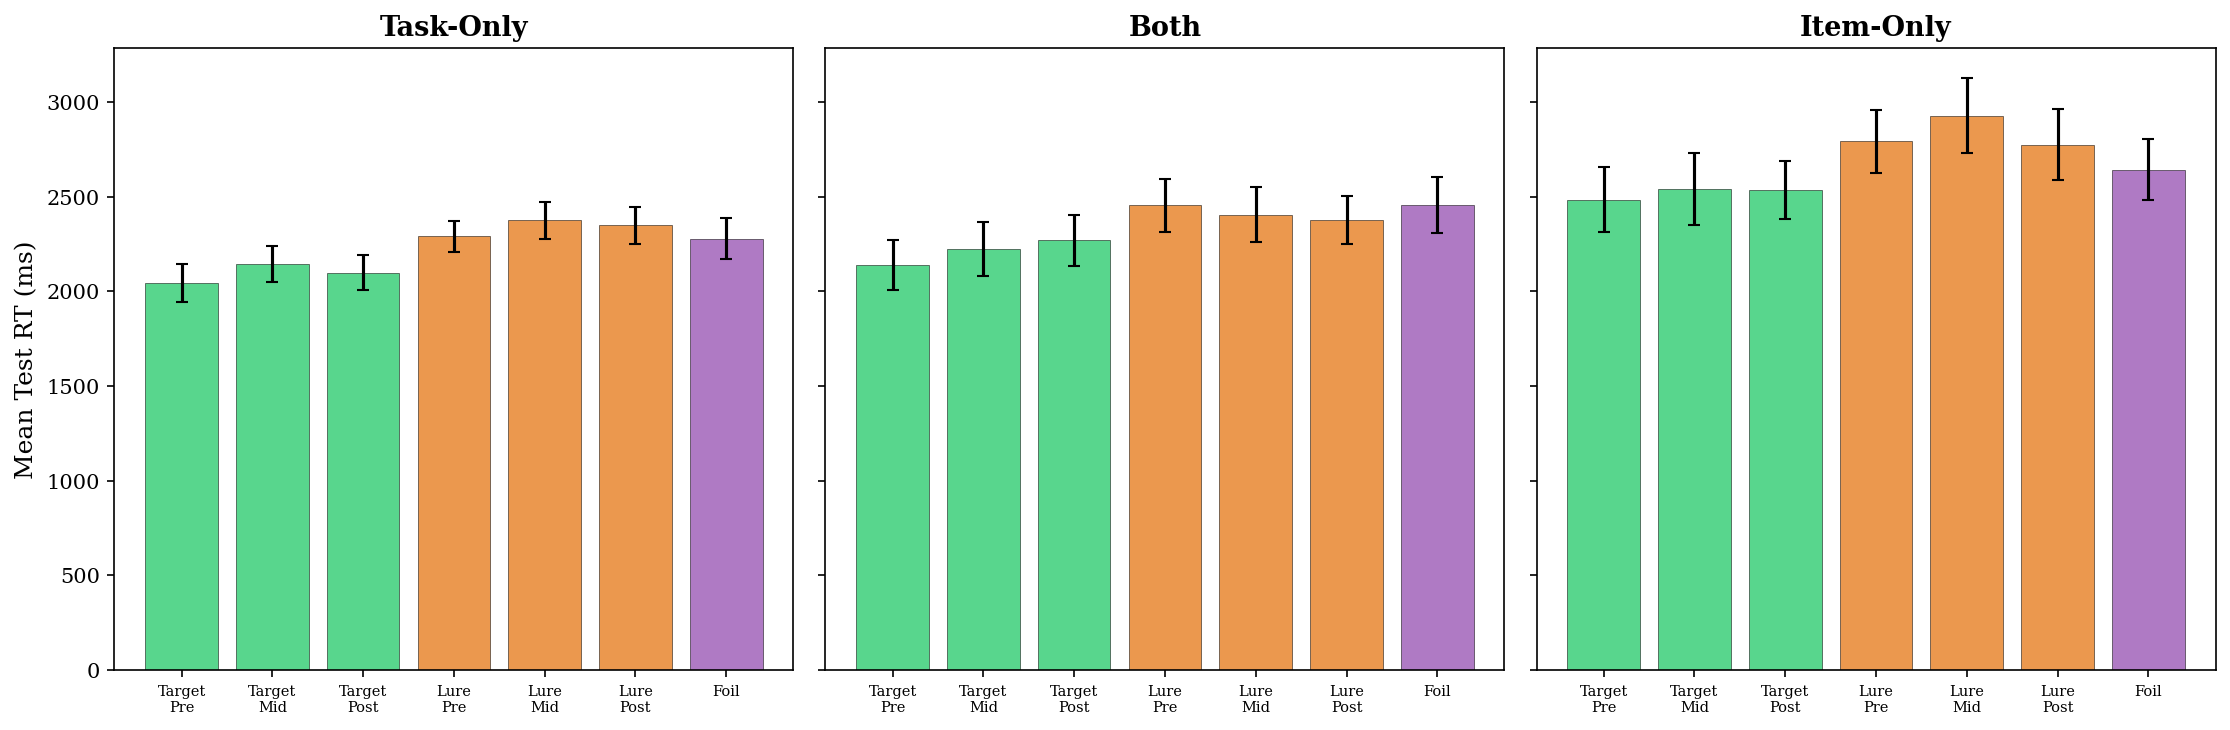

In [7]:
# ── Figure 6: Test-phase RT by item type and boundary position ──
fig, axes = plt.subplots(1, 3, figsize=(15, 5), sharey=True)
item_colors = {'Target': '#2ecc71', 'Lure': '#e67e22', 'Foil': '#9b59b6'}

test_rt_stats = {}

for idx, (cond, test_df) in enumerate(all_test.items()):
    ax = axes[idx]
    
    bar_labels, bar_means, bar_sems, bar_colors = [], [], [], []
    
    for it in ['Target', 'Lure']:
        for pos in ['Pre', 'Mid', 'Post']:
            sub = test_df[(test_df['item_type'] == it) & (test_df['position'] == pos)]
            prt = sub.groupby('participant')['test_rt'].mean()
            bar_labels.append(f'{it}\n{pos}')
            bar_means.append(prt.mean())
            bar_sems.append(prt.sem())
            bar_colors.append(item_colors[it])
    
    # Foil
    foil_sub = test_df[test_df['item_type'] == 'Foil']
    prt_foil = foil_sub.groupby('participant')['test_rt'].mean()
    bar_labels.append('Foil')
    bar_means.append(prt_foil.mean())
    bar_sems.append(prt_foil.sem())
    bar_colors.append(item_colors['Foil'])
    
    x = range(len(bar_labels))
    ax.bar(x, bar_means, yerr=bar_sems, capsize=3,
           color=bar_colors, alpha=0.8, edgecolor='black', linewidth=0.3)
    ax.set_xticks(x)
    ax.set_xticklabels(bar_labels, fontsize=7)
    ax.set_ylabel('Mean Test RT (ms)' if idx == 0 else '')
    ax.set_title(f'{cond}', fontweight='bold')
    
    # Compare Target Post vs Mid
    t_post = test_df[(test_df['item_type'] == 'Target') & (test_df['position'] == 'Post')]
    t_mid = test_df[(test_df['item_type'] == 'Target') & (test_df['position'] == 'Mid')]
    post_rt = t_post.groupby('participant')['test_rt'].mean()
    mid_rt = t_mid.groupby('participant')['test_rt'].mean()
    common = post_rt.index.intersection(mid_rt.index)
    if len(common) > 2:
        t_stat, p_val = stats.ttest_rel(post_rt[common], mid_rt[common])
        test_rt_stats[f'{cond}_Target_Post_vs_Mid'] = (t_stat, p_val)
        print(f'{cond} Target Post vs Mid RT: t={t_stat:.3f}, p={p_val:.4f}')

plt.tight_layout()
plt.savefig(BASE / 'fig6_test_rt.pdf', bbox_inches='tight')
plt.savefig(BASE / 'fig6_test_rt.png', bbox_inches='tight')
plt.show()

## 5. Encoding RT Predicts Subsequent Memory

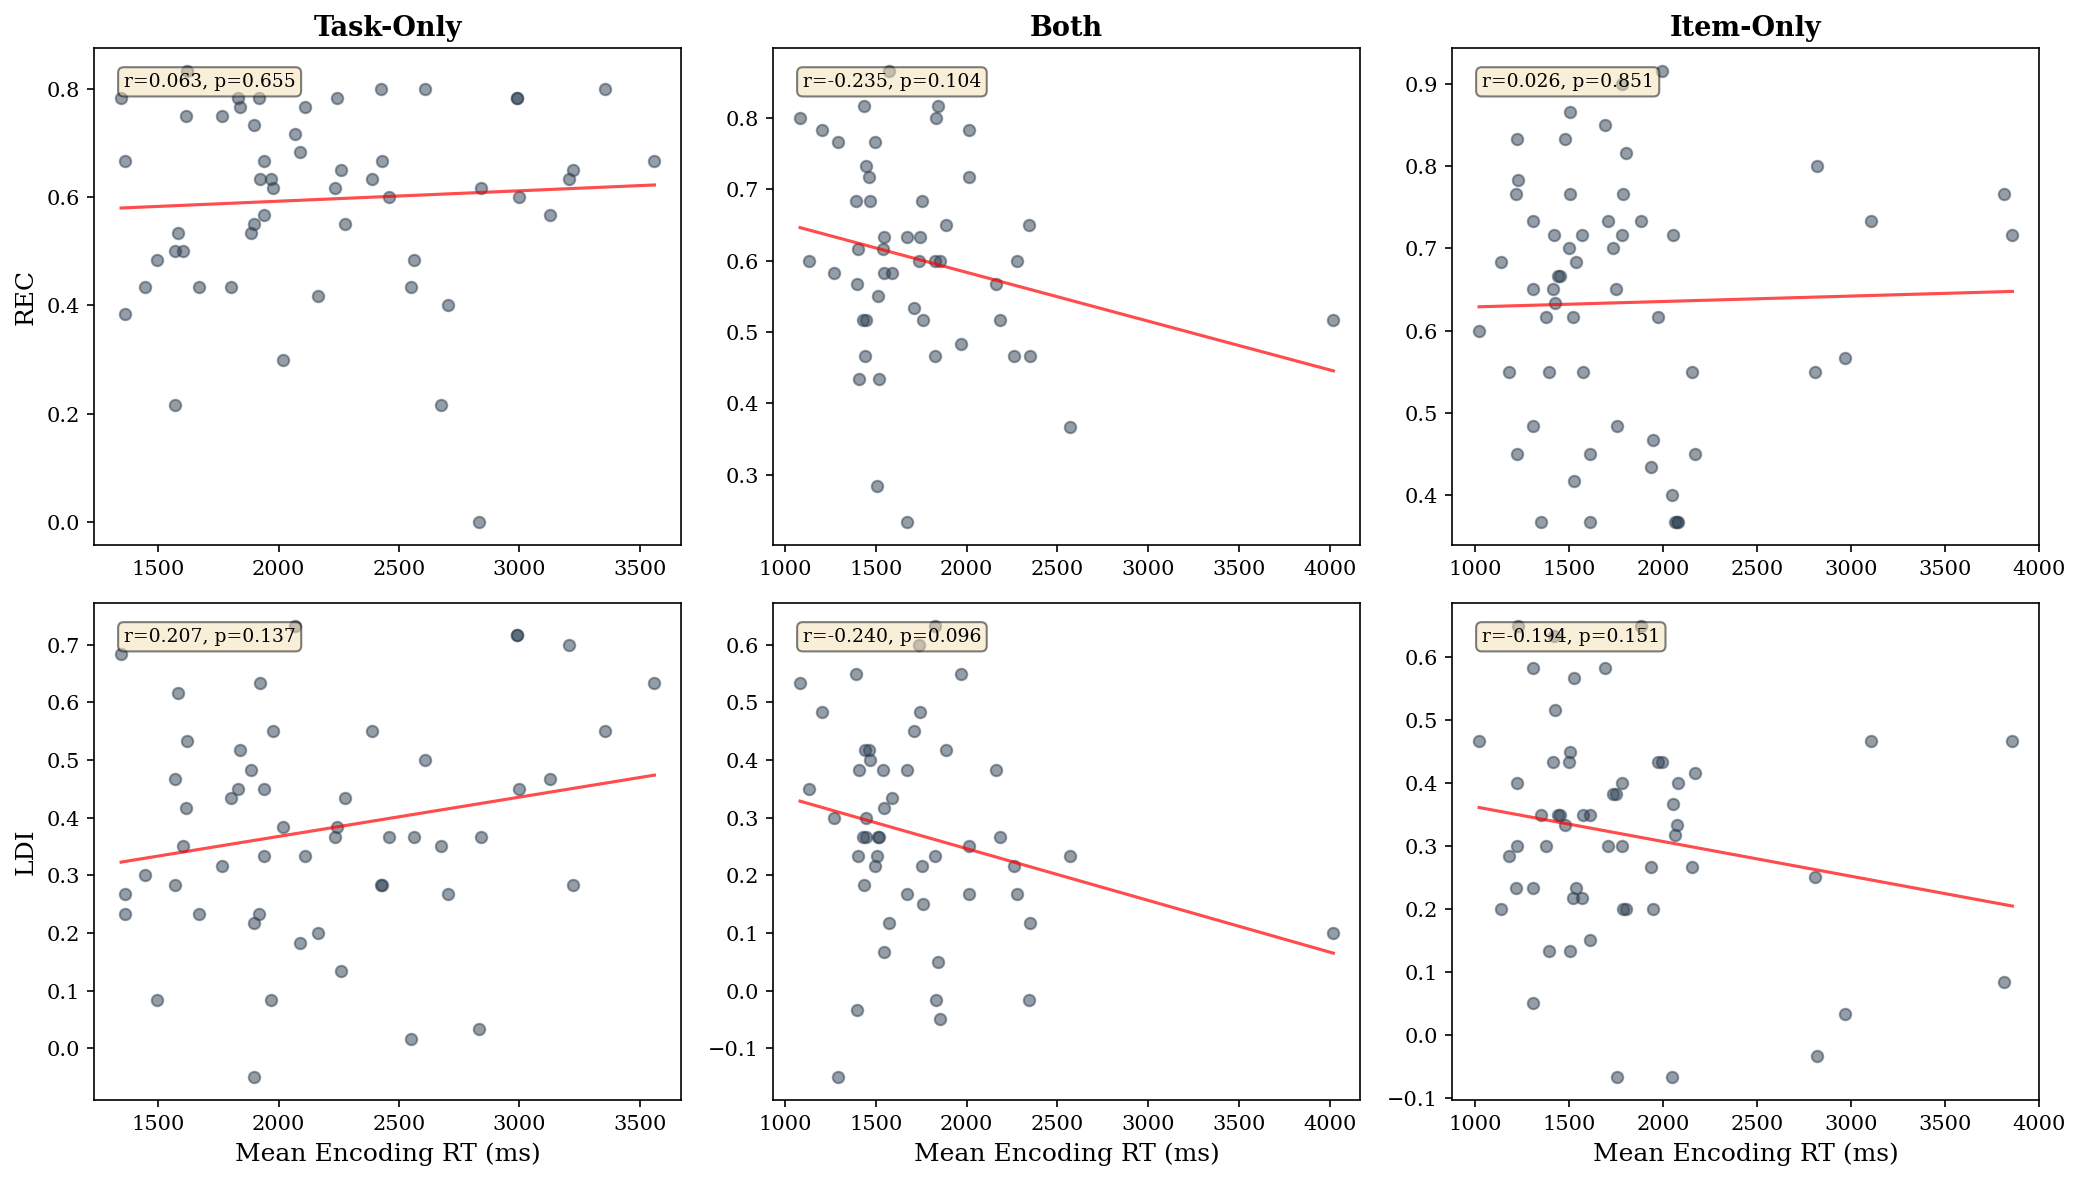

In [8]:
# ── Figure 8: Encoding RT vs subsequent REC/LDI correlation ──
fig, axes = plt.subplots(2, 3, figsize=(14, 8))

corr_stats = {}

for col_idx, (cond, enc_df) in enumerate(all_enc.items()):
    mean_rt = enc_df.groupby('participant')['rt_ms'].mean()
    rl = rec_ldi_all[cond]
    overall = rl.groupby('participant')[['REC', 'LDI']].mean()
    merged = pd.DataFrame({'mean_rt': mean_rt}).join(overall, how='inner')
    
    for row_idx, metric in enumerate(['REC', 'LDI']):
        ax = axes[row_idx, col_idx]
        x = merged['mean_rt']
        y = merged[metric]
        
        ax.scatter(x, y, alpha=0.5, s=30, color='#2c3e50')
        
        mask = ~(np.isnan(x) | np.isnan(y))
        if mask.sum() > 2:
            slope, intercept, r, p, se = stats.linregress(x[mask], y[mask])
            x_line = np.linspace(x[mask].min(), x[mask].max(), 100)
            ax.plot(x_line, slope * x_line + intercept, 'r-', linewidth=1.5, alpha=0.7)
            ax.text(0.05, 0.95, f'r={r:.3f}, p={p:.3f}',
                    transform=ax.transAxes, fontsize=9, va='top',
                    bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))
            corr_stats[f'{cond}_{metric}'] = (r, p)
        
        ax.set_xlabel('Mean Encoding RT (ms)' if row_idx == 1 else '')
        ax.set_ylabel(metric if col_idx == 0 else '')
        if row_idx == 0:
            ax.set_title(f'{cond}', fontweight='bold')

plt.tight_layout()
plt.savefig(BASE / 'fig8_rt_memory_corr.pdf', bbox_inches='tight')
plt.savefig(BASE / 'fig8_rt_memory_corr.png', bbox_inches='tight')
plt.show()

## 6. Effect Size Forest Plot

Cohen's d with 95% CIs for the key boundary effects across conditions.

In [9]:
# First compute baseline-corrected stats needed for the forest plot
bc_stats = {}
for cond, df in rec_ldi_all.items():
    for metric in ['REC', 'LDI']:
        wide = df.pivot(index='participant', columns='position', values=metric).dropna()
        delta_post = wide['Post'] - wide['Mid']
        delta_pre = wide['Pre'] - wide['Mid']
        
        t_post, p_post = stats.ttest_1samp(delta_post, 0)
        t_pre, p_pre = stats.ttest_1samp(delta_pre, 0)
        d_post = delta_post.mean() / delta_post.std() if delta_post.std() > 0 else 0
        d_pre = delta_pre.mean() / delta_pre.std() if delta_pre.std() > 0 else 0
        
        bc_stats[f'{cond}_{metric}'] = {
            'N': len(wide), 'd_post': d_post, 'p_post': p_post,
            'd_pre': d_pre, 'p_pre': p_pre,
            'Post_dM': delta_post.mean(), 'Post_dSD': delta_post.std(),
            'Pre_dM': delta_pre.mean(), 'Pre_dSD': delta_pre.std(),
            't_post': t_post, 't_pre': t_pre,
        }

print('Baseline-corrected effect sizes computed.')

Baseline-corrected effect sizes computed.


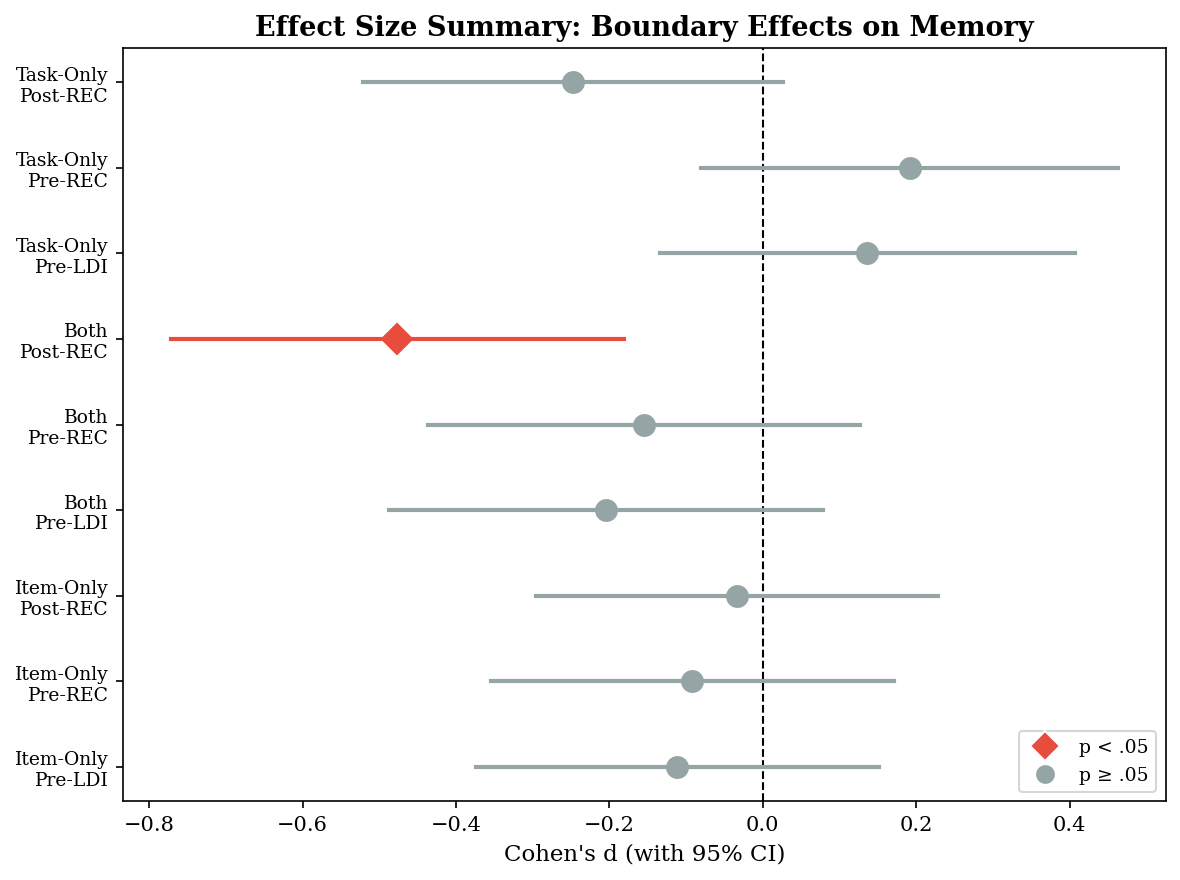

In [10]:
# ── Figure 13: Effect size forest plot ──
fig, ax = plt.subplots(figsize=(8, 6))

forest_data = []
forest_labels = []

for cond in ['Task-Only', 'Both', 'Item-Only']:
    for metric_label, key_suffix, pos_key in [
        ('Post-REC', 'REC', 'Post'),
        ('Pre-REC',  'REC', 'Pre'),
        ('Pre-LDI',  'LDI', 'Pre'),
    ]:
        s = bc_stats[f'{cond}_{key_suffix}']
        if pos_key == 'Post':
            d, p_val, n = s['d_post'], s['p_post'], s['N']
        else:
            d, p_val, n = s['d_pre'], s['p_pre'], s['N']
        
        # 95% CI for Cohen's d
        se_d = np.sqrt(1/n + d**2 / (2*n))
        ci_lo = d - 1.96 * se_d
        ci_hi = d + 1.96 * se_d
        
        forest_data.append((d, ci_lo, ci_hi, p_val))
        forest_labels.append(f'{cond}\n{metric_label}')

for i, (d, ci_lo, ci_hi, p_val) in enumerate(forest_data):
    color = '#e74c3c' if p_val < 0.05 else '#95a5a6'
    marker = 'D' if p_val < 0.05 else 'o'
    ax.plot(d, i, marker, color=color, markersize=10, zorder=5)
    ax.plot([ci_lo, ci_hi], [i, i], '-', color=color, linewidth=2, zorder=4)

ax.axvline(0, color='black', linestyle='--', linewidth=1)
ax.set_yticks(range(len(forest_data)))
ax.set_yticklabels(forest_labels, fontsize=9)
ax.set_xlabel("Cohen's d (with 95% CI)", fontsize=11)
ax.set_title('Effect Size Summary: Boundary Effects on Memory', fontweight='bold')
ax.invert_yaxis()

# Legend
legend_elements = [
    Line2D([0], [0], marker='D', color='w', markerfacecolor='#e74c3c',
           markersize=10, label='p < .05'),
    Line2D([0], [0], marker='o', color='w', markerfacecolor='#95a5a6',
           markersize=10, label='p ≥ .05'),
]
ax.legend(handles=legend_elements, loc='lower right', fontsize=9)

plt.tight_layout()
plt.savefig(BASE / 'fig13_effect_size_forest.pdf', bbox_inches='tight')
plt.savefig(BASE / 'fig13_effect_size_forest.png', bbox_inches='tight')
plt.show()

## 7. Comprehensive Summary Statistics

In [11]:
print('=' * 80)
print('COMPREHENSIVE SUMMARY FOR REPORT')
print('=' * 80)

cond_order = ['Task-Only', 'Both', 'Item-Only']

for cond in cond_order:
    print(f'\n{"="*40}')
    print(f'CONDITION: {cond}')
    print(f'{"="*40}')
    
    enc_df = all_enc[cond]
    test_df = all_test[cond]
    rl = rec_ldi_all[cond]
    
    N = enc_df['participant'].nunique()
    print(f'N = {N}')
    
    # Encoding accuracy
    acc = enc_df.groupby('participant')['encoding_accuracy'].first()
    print(f'Encoding Accuracy: M={acc.mean():.3f}, SD={acc.std():.3f}')
    
    # Encoding RT
    print('\nEncoding RT (ms):')
    for pos in ['Post', 'Mid', 'Pre']:
        prt = enc_df[enc_df['boundary_pos']==pos].groupby('participant')['rt_ms'].mean()
        print(f'  {pos}: M={prt.mean():.1f}, SD={prt.std():.1f}')
    
    # REC & LDI
    print('\nREC:')
    wide_rec = rl.pivot(index='participant', columns='position', values='REC')
    for pos in ['Pre', 'Mid', 'Post']:
        print(f'  {pos}: M={wide_rec[pos].mean():.3f}, SD={wide_rec[pos].std():.3f}')
    
    print('\nLDI:')
    wide_ldi = rl.pivot(index='participant', columns='position', values='LDI')
    for pos in ['Pre', 'Mid', 'Post']:
        print(f'  {pos}: M={wide_ldi[pos].mean():.3f}, SD={wide_ldi[pos].std():.3f}')
    
    # Baseline-corrected t-tests
    print('\nBaseline-Corrected Tests:')
    for metric in ['REC', 'LDI']:
        wide = rl.pivot(index='participant', columns='position', values=metric)
        for pos in ['Post', 'Pre']:
            delta = (wide[pos] - wide['Mid']).dropna()
            t, p = stats.ttest_1samp(delta, 0)
            d = delta.mean() / delta.std()
            print(f'  {metric} {pos} Δ: M={delta.mean():.3f}, SD={delta.std():.3f}, '
                  f't({len(delta)-1})={t:.3f}, p={p:.4f}, d={d:.3f}')

# RT-memory correlations
print('\n\nRT–Memory Correlations:')
for key, (r, p) in corr_stats.items():
    print(f'  {key}: r={r:.3f}, p={p:.4f}')

# Test RT stats
print('\nTest RT Stats:')
for key, (t, p) in test_rt_stats.items():
    print(f'  {key}: t={t:.3f}, p={p:.4f}')

COMPREHENSIVE SUMMARY FOR REPORT

CONDITION: Task-Only
N = 53
Encoding Accuracy: M=0.943, SD=0.042

Encoding RT (ms):
  Post: M=2399.1, SD=561.9
  Mid: M=2163.5, SD=581.0
  Pre: M=2131.6, SD=575.8

REC:
  Pre: M=0.624, SD=0.195
  Mid: M=0.601, SD=0.183
  Post: M=0.563, SD=0.204

LDI:
  Pre: M=0.387, SD=0.205
  Mid: M=0.369, SD=0.180
  Post: M=0.386, SD=0.229

Baseline-Corrected Tests:
  REC Post Δ: M=-0.038, SD=0.153, t(52)=-1.801, p=0.0775, d=-0.247
  REC Pre Δ: M=0.024, SD=0.123, t(52)=1.395, p=0.1690, d=0.192
  LDI Post Δ: M=0.017, SD=0.158, t(52)=0.782, p=0.4378, d=0.107
  LDI Pre Δ: M=0.019, SD=0.138, t(52)=0.992, p=0.3256, d=0.136

CONDITION: Both
N = 49
Encoding Accuracy: M=0.947, SD=0.032

Encoding RT (ms):
  Post: M=1922.3, SD=514.8
  Mid: M=1702.4, SD=461.2
  Pre: M=1679.6, SD=531.0

REC:
  Pre: M=0.612, SD=0.153
  Mid: M=0.634, SD=0.171
  Post: M=0.561, SD=0.162

LDI:
  Pre: M=0.261, SD=0.186
  Mid: M=0.292, SD=0.221
  Post: M=0.258, SD=0.188

Baseline-Corrected Tests:
  REC